In [1]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import matplotlib.pyplot as plt

from Equations_Run_Combo_V_2 import *
from Results_Dists_V_2 import *

import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


#/home/charifslmn/

---
# Part 1 - GS Results 
---

In [2]:

for i in range(1):  
    with open(f'/Users/cs/Desktop/GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json', 'r') as f:
        results_all_gs = json.load(f)



In [3]:
with open ('results_H_top_30_GS_combos_T_mac HOD 20_01 - 21_12.pkl' , 'rb') as f:
    results = pickle.load(f)


In [4]:
import json
import numpy as np
import copy


scored_results = []
for entry in results_all_gs:
    avg = entry['cv_sets'].get('overall_metrics', {})
    acc = avg.get('accuracy') or 0.0
    prec_up = avg.get('precision_up') or 0.0
    recall_up = avg.get('recall_up') or 0.0

    total_score = acc  # or add prec_up, etc.
    
    if recall_up > 10 and prec_up > 65:

        scored_results.append((total_score, entry))

# Step 2: Sort by score descending
scored_results.sort(reverse=True, key=lambda x: x[0])


top = scored_results[:80]

for i, j in top:
    print(j["combo_number"], '<--->' , j["cv_sets"]["overall_metrics"] , '<---->' , j["parameters"] )

# Step 4: Extract the parameter combos
combos = [j["parameters"] for i, j in top]

print(f"Total Combos Selected: {len(top)}")


random.seed(42)
top_random = random.sample(top, 30)

1279 <---> {'accuracy': 87.5, 'precision_up': 100.0, 'recall_up': 50.0, 'precision_down': 85.71428571428571, 'recall_down': 100.0} <----> {'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.005, 'num_epochs': 70, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 1, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 1.5, 'use_rolling_fixed_train_size': False, 'use_existing_initial_we

In [5]:
val_results_finding = []  #### i had randomly chosen the vals and did not initailize a seed ... 

ignore = ['val_start_month', 'val_end_month']
for true in results:
    tt = str({k: v for k, v in true['parameters'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in top:
        ff = str({k: v for k, v in find[1]['parameters'].items() if k not in ignore}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if tt == ff:
            val_results_finding.append(find)



val_results_finding_fix = [i[1] for i in val_results_finding]

res_mac_H_test = results
res_mac_H_val = val_results_finding_fix ### this is actually mac but c4d preforms similartly enough


# with open ('results_H_top_30_GS_combos_V_gc HOD 20_01 - 21_12.pkl' , 'wb') as f:
#     pickle.dump(res_mac_H_val, f) 



In [14]:

# Add threshold metrics
names_all = [ res_mac_H_val, res_mac_H_test]

names_test = [ res_mac_H_test]
names_val = [ res_mac_H_val]


for data in names_all:
    add_threshold_metrics(data, threshold=.7)


# Create DataFrames

df_mac_H_val = flatten_results(res_mac_H_val)

df_mac_H_test = flatten_results(res_mac_H_test)

# Add H/L labels

df_mac_H_val['H_L'] = 'H'

df_mac_H_test['H_L'] = 'H'

dfs = [df_mac_H_val, df_mac_H_test]

# Add various metrics
add_up_prediction_counts(dfs)
add_false_correct_up_stats(dfs)
flatten_metrics_columns(dfs)


master_df = process_parameters_and_merge(dfs)




In [15]:
display(master_df[[
    "OA_prec_1_mac_V", "OA_rec_1_mac_V", "no_1_preds_mac_V", "actuals_false_1_mac_V",
    'false_1_preds_mac_V', 'correct_1_preds_mac_V', 'actuals_correct_1_mac_V',
    "OA_prec_1_mac_T", "OA_rec_1_mac_T", "no_1_preds_mac_T", "actuals_false_1_mac_T",
    'false_1_preds_mac_T', 'correct_1_preds_mac_T', 'actuals_correct_1_mac_T',
    "H_L_mac_T", "H_L_mac_V", "param_int_Vue_mac_T"
]].round(4))


,OA_prec_1_mac_V,OA_rec_1_mac_V,no_1_preds_mac_V,actuals_false_1_mac_V,false_1_preds_mac_V,correct_1_preds_mac_V,actuals_correct_1_mac_V,OA_prec_1_mac_T,OA_rec_1_mac_T,no_1_preds_mac_T,actuals_false_1_mac_T,false_1_preds_mac_T,correct_1_preds_mac_T,actuals_correct_1_mac_T,H_L_mac_T,H_L_mac_V,param_int_Vue_mac_T
0,66.6667,33.3333,3,[-0.0395],[0.5817],"[0.5237, 0.5778]","[0.422, 0.1014]",33.3333,50.0,3,"[-0.2349, -0.1754]","[0.6072, 0.6079]",[0.5871],[0.2874],H,H,12
1,66.6667,66.6667,6,"[-0.1521, -0.1128]","[0.5002, 0.5001]","[0.5005, 0.5007, 0.5014, 0.5002]","[0.3069, 0.1856, 1.1117, 0.422]",NaN,0.0,0,[],[],[],[],H,H,8
2,66.6667,33.3333,3,[0.051],[0.7075],"[0.5244, 0.7495]","[0.1014, 0.1347]",25.0000,50.0,4,"[-0.2349, 0.0667, 0.0101]","[0.6893, 0.7592, 0.7247]",[0.616],[0.2874],H,H,6
3,66.6667,33.3333,3,[-0.053],[0.8259],"[0.8658, 0.9694]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0101],[0.8849],[],[],H,H,9
4,100.0000,33.3333,2,[],[],"[0.6665, 0.7382]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0101],[0.8368],[],[],H,H,0
5,100.0000,33.3333,2,[],[],"[0.9136, 0.8162]","[1.1117, 0.1014]",NaN,0.0,0,[],[],[],[],H,H,11
6,75.0000,50.0000,4,[-0.0504],[0.9986],"[0.9996, 0.625, 0.9317]","[1.1117, 0.422, 0.1347]",0.0000,0.0,1,[0.0667],[0.857],[],[],H,H,24
7,100.0000,33.3333,2,[],[],"[0.9937, 0.9138]","[0.422, 0.1347]",0.0000,0.0,4,"[-0.1754, 0.0354, 0.0269, -0.2069]","[0.5815, 0.5085, 0.5816, 0.7018]",[],[],H,H,23
8,100.0000,33.3333,2,[],[],"[0.9986, 0.9998]","[1.1117, 0.1347]",0.0000,0.0,1,[0.0667],[0.6936],[],[],H,H,21
9,100.0000,33.3333,2,[],[],"[0.9996, 0.9997]","[0.3069, 0.422]",33.3333,100.0,6,"[-0.1754, -0.4469, 0.0667, -0.2069]","[0.9989, 0.9991, 0.999, 0.9999]","[0.9999, 0.9162]","[0.2874, 0.1502]",H,H,16


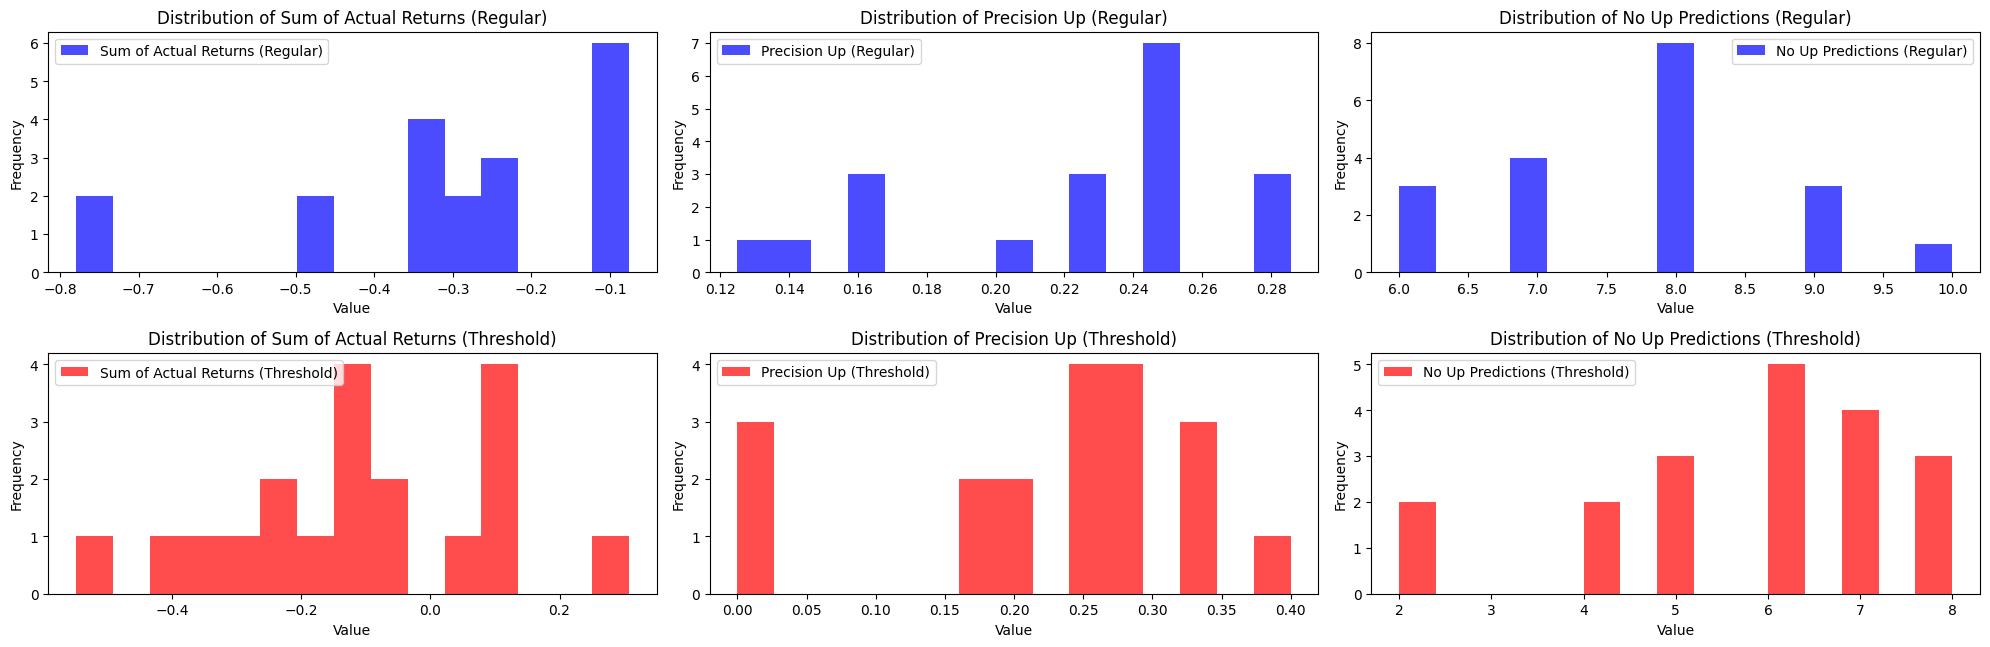

ALL Realizations Regular Unique Actuals Ups: {np.float64(0.01014370245139462), np.float64(0.28744769874477005), np.float64(0.06672678088367912), np.float64(0.15017414464249113), np.float64(-0.23493562231759657), np.float64(-0.20685732856678574), np.float64(-0.17536183103332204), np.float64(-0.4469387755102041), np.float64(-0.2302209550962223), np.float64(0.026851851851851682)}
ALL Realizations Regular Unique Actuals Ups Sum: -0.7529703339499442
Total Unique Up Preds Regular: 10
ALL Realizations Threshold Unique Actuals Ups: {np.float64(0.01014370245139462), np.float64(-0.17536183103332204), np.float64(0.28744769874477005), np.float64(0.15017414464249113), np.float64(-0.20685732856678574), np.float64(0.06672678088367912), np.float64(-0.23493562231759657), np.float64(-0.4469387755102041), np.float64(0.026851851851851682)}
ALL Realizations Threshold Unique Actuals Ups Sum: -0.5227493788537219
Total Unique Up Preds Threshold: 9


In [16]:
#####       PURPOSE - THIS IS JSUT FOR TESTING 



names_all = { 'res_mac_H_val': res_mac_H_val, 
             'res_mac_H_test': res_mac_H_test}

# Define your groups configuration
groups_config = [
    ("mac",  (-1, 1), 2),
    # ("mac",  (0.1, 0.2), 2),
    # ("mac",  (0.3, 0.5), 2),
    # ("mac",  (-1, 0.3), 3),
    # ("mac",  (0.1, 0.3), 3),
    # ("mac",  (0.3, 0.5), 3)
]


number_realizations = 20

all_results_regular = []
all_results_threshold = []

# random_seeds_seed = 4
# random.seed(random_seeds_seed)


sample_size = number_realizations
seeds = random.sample(range(1, 100000), sample_size)

for i, seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = False,
                                    seed = None,
                                    no_maps_per_group = 30,
                                    filter_outliers = False ,#### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4 ,


                                    )
    all_results_regular.append(results)


for i , seed in zip(range(1, number_realizations), seeds):

    results = process_func_PLUS_return_analytics_THRESH_var_included (
                                        ## new params
                                    threshold = 0.7,
                                    names_all = names_all,

                                    #new arams

                                    groups_config = groups_config,
                                    data_type_corr_groups_creation = "V",
                                    data_type_ensemble = "T",
                                    use_threshold_data = True,
                                    seed = None,
                                    no_maps_per_group = 30,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 3 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                    )

    all_results_threshold.append(results)

all_groups_prec_up_regular = []
all_groups_total_return_regular = []
no_up_preds_per_group_regular = []
all_realizations_unique_actuals_ups_regular = []



        # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
        # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
        # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

for seed_res in all_results_regular:
    #first set of plots 
    all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_regular.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_regular_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_regular for item in sublist])
all_realizations_unique_actuals_ups_regular_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_regular_UNIQUE)


    

all_groups_prec_up_threshold = []
all_groups_total_return_threshold = []
no_up_preds_per_group_threshold = []
all_realizations_unique_actuals_ups_threshold = []



for seed_res in all_results_threshold:
    all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
    all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
    no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])
    all_realizations_unique_actuals_ups_threshold.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


all_realizations_unique_actuals_ups_threshold_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_threshold for item in sublist])
all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_threshold_UNIQUE)



# {'group_results': {'pair_2_neg03_01': ['None - 0 (3, 9) - 0 - Correct: 0 - []', 'None - 0 (3, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (1, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 12) - 0 - Correct: 0 - []', 'None - 0 (6, 13) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 4) - 0 - Correct: 0 - []', 'None - 0 (13, 14) - 0 - Correct: 0 - []', 'None - 0 (5, 8) - 0 - Correct: 0 - []', 
# 'None - 0 (3, 15) - 0 - Correct: 0 - []', 'None - 0 (14, 15) - 0 - Correct: 0 - []'], 'pair_2_neg03_01_summary':
#  ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_01_03': ['None - 0 (7, 10) - 0 - Correct: 0 - []', 'None - 0 (2, 7) - 0 - Correct: 0 - []', 'None - 0 (3, 5) - 0 - Correct: 0 - []', 'None - 0 (5, 10) - 0 - Correct: 0 - []', 'None - 0 (5, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7) - 0 - Correct: 0 - []', 'None - 0 (6, 9) - 0 - Correct: 0 - []', 'None - 0 (10, 13) - 0 - Correct: 0 - []', 'None - 0 (7, 13) - 0 - Correct: 0 - []', 'None - 0 (10, 11) - 0 - Correct: 0 - []'], 'pair_2_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_2_03_05': ['None - 0 (11, 13) - 0 - Correct: 0 - []', 'None - 0 (6, 12) - 0 - Correct: 0 - []', 'None - 0 (9, 13) - 0 - Correct: 0 - []', 'None - 0 (8, 15) - 0 - Correct: 0 - []', 'None - 0 (4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 11) - 0 - Correct: 0 - []', 'None - 0 (12, 15) - 0 - Correct: 0 - []', 'None - 0 (3, 14) - 0 - Correct: 0 - []', 'None - 0 (3, 6) - 0 - Correct: 0 - []', 'None - 0 (2, 9) - 0 - Correct: 0 - []'], 'pair_2_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_neg03_01': ['None - 0 (1, 3, 7) - 0 - Correct: 0 - []', 'None - 0 (5, 6, 15) - 0 - Correct: 0 - []', 'None - 0 (1, 3, 15) - 0 - Correct: 0 - []'], 'pair_3_neg03_01_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_01_03': ['None - 0 (5, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 14) - 0 - Correct: 0 - []', 'None - 0 (6, 7, 10) - 0 - Correct: 0 - []', 'None - 0 (7, 10, 13) - 0 - Correct: 0 - []'], 'pair_3_01_03_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'pair_3_03_05': ['None - 0 (1, 4, 6) - 0 - Correct: 0 - []', 'None - 0 (6, 8, 12) - 0 - Correct: 0 - []', 'None - 0 (4, 6, 8) - 0 - Correct: 0 - []', 'None - 0 (2, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (4, 7, 9) - 0 - Correct: 0 - []', 'None - 0 (4, 8, 9) - 0 - Correct: 0 - []', 'None - 0 (8, 12, 14) - 0 - Correct: 0 - []', 'None - 0 (4, 9, 13) - 0 - Correct: 0 - []', 'None - 0 (1, 4, 8) - 0 - Correct: 0 - []', 'None - 0 (1, 6, 8) - 0 - Correct: 0 - []'], 'pair_3_03_05_summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000']}, 'detailed_results': {'pair_2_neg03_01': [{'combo_numbers': (3, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 4), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (13, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (14, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_01_03': [{'combo_numbers': (7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 5), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (10, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_2_03_05': [{'combo_numbers': (11, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 11), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (12, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (3, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_neg03_01': [{'combo_numbers': (1, 3, 7), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (5, 6, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 3, 15), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_01_03': [{'combo_numbers': (5, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 7, 10), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (7, 10, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}], 'pair_3_03_05': [{'combo_numbers': (1, 4, 6), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (6, 8, 12), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (2, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 7, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 8, 9), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (8, 12, 14), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (4, 9, 13), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 4, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}, {'combo_numbers': (1, 6, 8), 'precision_up': None, 'recall_up': 0, 'up_predictions': 0, 'correct_ups': 0, 'actual_returns': []}]}, 'summary': ['Total Up Predictions: 0', 'Total Correct Up Predictions: 0', 'Sum of Actual Returns for Up Predictions: 0.000', 'Prec Up: 0.000'], 'total_metrics': {'total_ups': 0, 'total_correct_ups': 0, 'sum_actuals_ups': 0, 'precision': 0}, 'config_info': {'groups_config': [('mac', 'V', (-0.3, 0.1), 2), ('mac', 'V', (0.1, 0.3), 2), ('mac', 'V', (0.3, 0.5), 2), ('mac', 'V', (-0.3, 0.1), 3), ('mac', 'V', (0.1, 0.3), 3), ('mac', 'V', (0.3, 0.5), 3)], 'data_type_corr_groups_creation': 'V', 'data_type_ensemble': 'T', 'use_threshold_data': True, 'seed': None, 'no_maps_per_group': 10}}
import matplotlib.pyplot as plt

# List of variable names and titles
metrics = [
    
    (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
    (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
    (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

    (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
    (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
    (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),


]

plt.figure(figsize=(20, 19))

for i, (var_name, title, color) in enumerate(metrics, 1):

    plt.subplot(6, 3, i)
    data = var_name  # Get the variable by name
    plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {title}')
    plt.legend()

plt.tight_layout()
plt.show()




print("ALL Realizations Regular Unique Actuals Ups:", all_realizations_unique_actuals_ups_regular_UNIQUE)
print("ALL Realizations Regular Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_regular_UNIQUE_SUM)
print("Total Unique Up Preds Regular:", len(all_realizations_unique_actuals_ups_regular_UNIQUE))

print("ALL Realizations Threshold Unique Actuals Ups:", all_realizations_unique_actuals_ups_threshold_UNIQUE)
print("ALL Realizations Threshold Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM)
print("Total Unique Up Preds Threshold:", len(all_realizations_unique_actuals_ups_threshold_UNIQUE))


In [18]:
res_mac_H_val[0]

{'combo_number': 2874,
 'parameters': {'binary_0_1_cutoff_ret_rate_percentage': 0.1,
  'learning_rate': 0.005,
  'num_epochs': 150,
  'batch_size': 10,
  'use_bidirectional': False,
  'lag': 2,
  'input_size': 12,
  'hidden_size': 55,
  'num_layers': 1,
  'use_monthly_dfs_only': True,
  'use_binary_0_1_retRate': False,
  'use_custom_loss_function_BCE_THRESH': True,
  'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False,
  'use_LOW_weights_for_BCE_custom_loss': True,
  'pred_threshold_sigmoid01_up': None,
  'use_binary_neg1_1': False,
  'use_ret_rate': False,
  'use_print_acc': False,
  'use_dropout': False,
  'use_class_weighting': True,
  'is_deterministic': True,
  'seed_num': 42,
  'use_existing_lagged_data': True,
  'use_dynamic_weights': False,
  'use_binary_0_1_retRate_custom_neg': False,
  'use_binary_0_1_retRate_custom_pos': True,
  'POS_weight_multiplier': 0.1,
  'use_rolling_fixed_train_size': False,
  'use_existing_initial_weights': False,
  'state_dict': None,
  'use_U

In [17]:
##### Threshold Discovery Process 

#####                                   PURPOSE - RUN FOR DIFFERENT THRESHOLDS AND PLOT RESULTS

def thresh(THRESH , data_type_corr_groups_creation ,data_type_ensemble ):

    names_all = { 'res_mac_H_val': res_mac_H_val, 
                 'res_mac_H_test': res_mac_H_test}


    # Define your groups configuration
    groups_config = [
        ("mac", (-1, 1), 2),
        # ("mac",  (0.1, 0.3), 2),
        # ("mac",  (0.3, 0.5), 2),
        # ("mac",  (-0.3, 0.1), 3),
        # ("mac",  (0.1, 0.3), 3),
        # ("mac",  (0.3, 0.5), 3)
    ]

    number_realizations = 40

    all_results_regular = []
    all_results_threshold = []


    random_seeds_seed = 400
    random.seed(random_seeds_seed)


    sample_size = number_realizations
    seeds = random.sample(range(1, 100000), sample_size)
    

    for i ,seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = THRESH,
                                        names_all = names_all,
                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = data_type_corr_groups_creation,
                                        data_type_ensemble = data_type_ensemble,
                                        use_threshold_data = False,
                                        seed = None,
                                        no_maps_per_group = 10,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 2 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                        )
        all_results_regular.append(results)

    for i ,seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = THRESH,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = data_type_corr_groups_creation,
                                        data_type_ensemble = data_type_ensemble,
                                        use_threshold_data = True,
                                        seed = None,
                                        no_maps_per_group = 10,
                                    filter_outliers = False, #### NOTICE NOTICE
                                    use_corr_with_diff_params = False,

                                    min_diff_params = 2 , 
                                    use_spearman_corr = False,
                                    
                                    use_corr_with_same_up_preds = True,
                                    min_same_up_preds = 1,
                                    max_same_up_preds = 4,

                                        )

        all_results_threshold.append(results)

    all_groups_prec_up_regular = []
    all_groups_total_return_regular = []
    no_up_preds_per_group_regular = []

    HOD_all_groups_total_return_regular = []
    UCO_all_groups_total_return_regular = []
    HUC_all_groups_total_return_regular = []
    CRUD_all_groups_total_return_regular = []
    USO_all_groups_total_return_regular = []

            # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
            # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
            # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

    for seed_res in all_results_regular:
        #first set of plots 
        all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])

        
    all_groups_prec_up_threshold = []
    all_groups_total_return_threshold = []
    no_up_preds_per_group_threshold = []


    for seed_res in all_results_threshold:
        all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])




    import matplotlib.pyplot as plt

    # List of variable names and titles
    metrics = [
        
        (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
        (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
        (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

        (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
        (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
        (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),

    ]


    import io
    import matplotlib.pyplot as plt

    # Create a bytes buffer to save the figure
    buffer = io.BytesIO()

    plt.figure(figsize=(20, 19))

    for i, (var_name, title, color) in enumerate(metrics, 1):
        plt.subplot(6, 3, i)
        data = var_name  # Get the variable by name
        plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {title}')
        plt.legend()

    plt.tight_layout()

    # Save the figure to the bytes buffer
    plt.savefig(buffer, format='png', dpi=300, bbox_inches='tight')
    plt.close()  # Close the figure to free memory

    # Get the bytes data
    figure_bytes = buffer.getvalue()
    buffer.close()

    return THRESH, figure_bytes

    # Now you can use figure_bytes as needed
    # For example: return figure_bytes, save to file, send over network, etc.

from joblib import Parallel, delayed , parallel_backend

with parallel_backend('loky'):
    res = Parallel(n_jobs=-1)(delayed(thresh)(THRESH , data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "V") for THRESH in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9 , 0.95])
    
with parallel_backend('loky'):
    res2 = Parallel(n_jobs=-1)(delayed(thresh)(THRESH , data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T") for THRESH in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9 , 0.95])
    




Threshold: 0.5


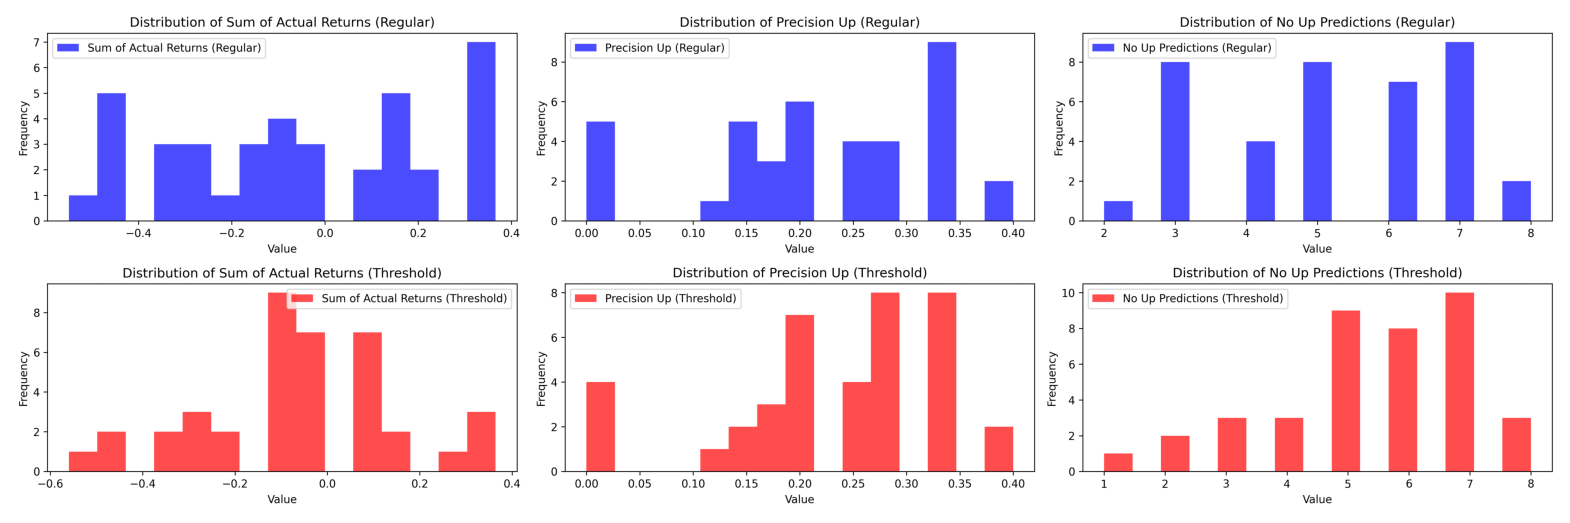

Threshold: 0.55


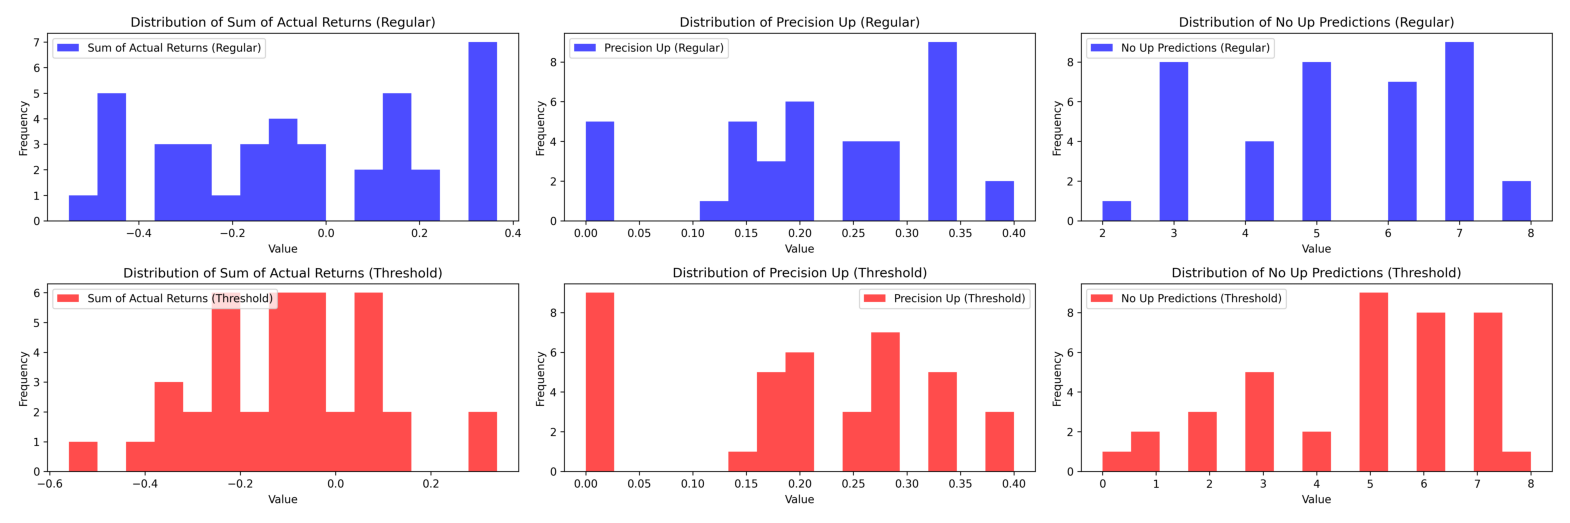

Threshold: 0.6


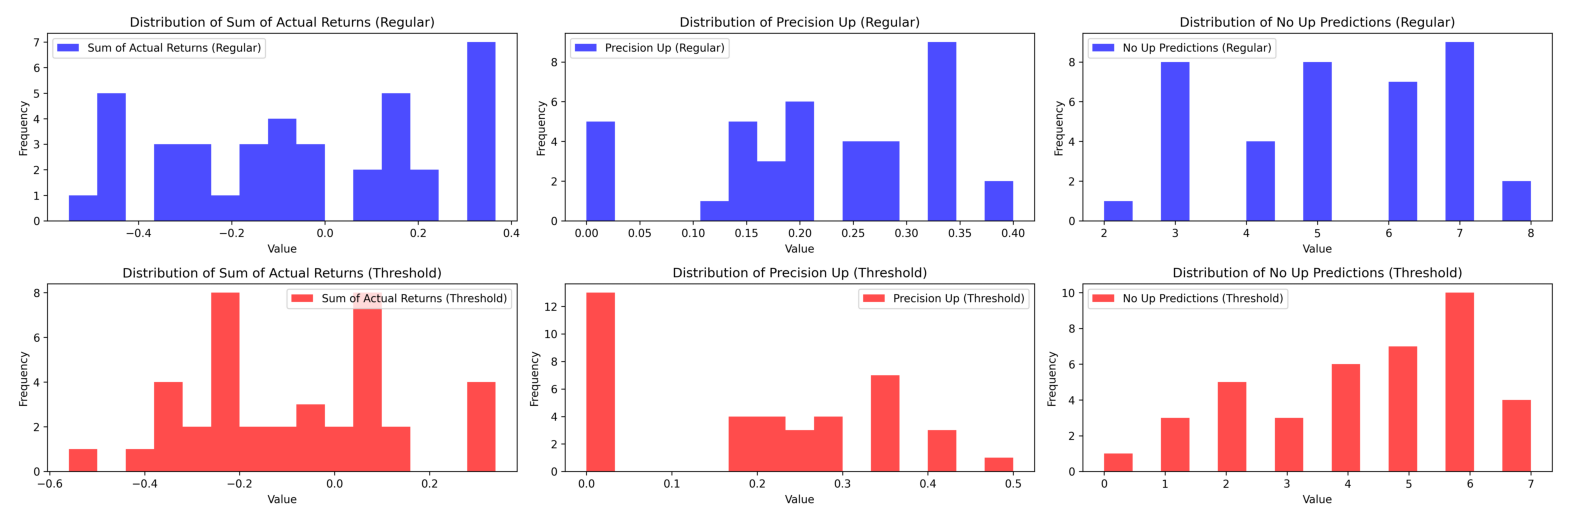

Threshold: 0.65


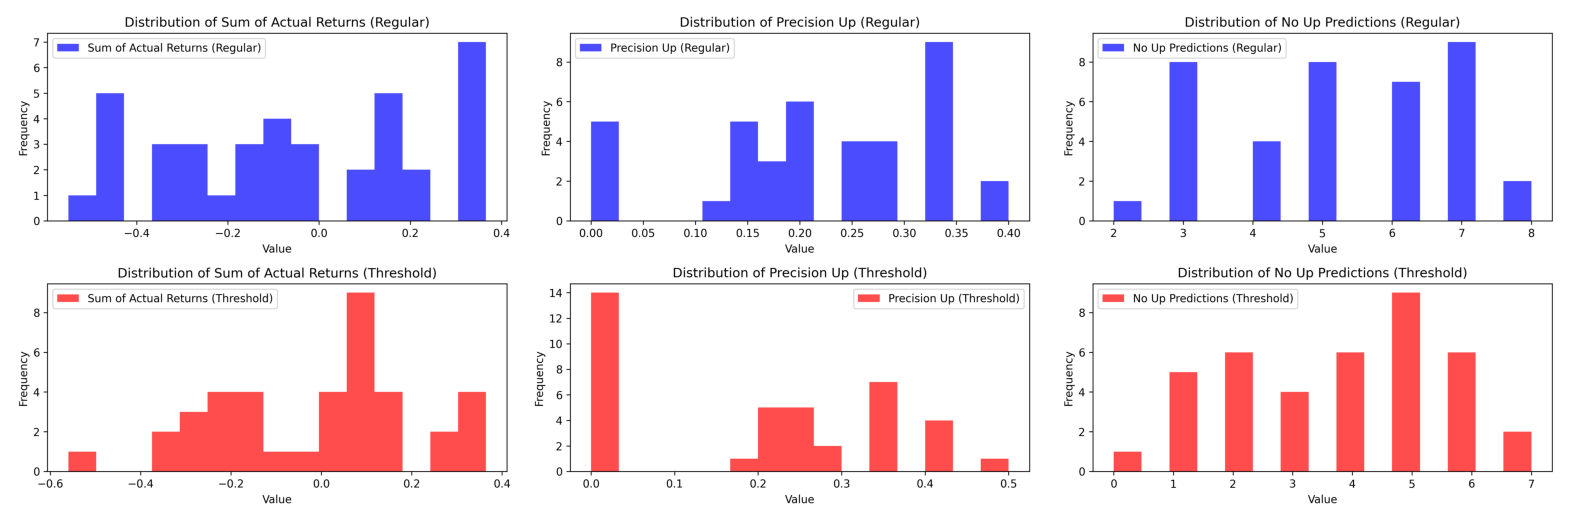

Threshold: 0.7


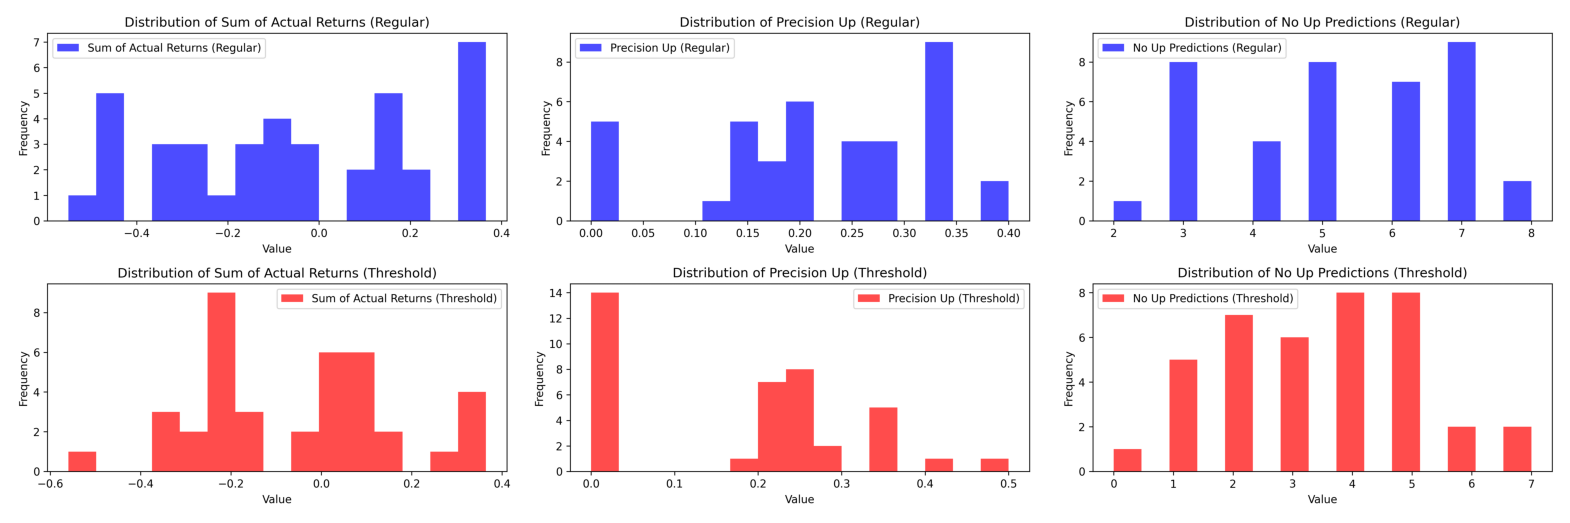

Threshold: 0.75


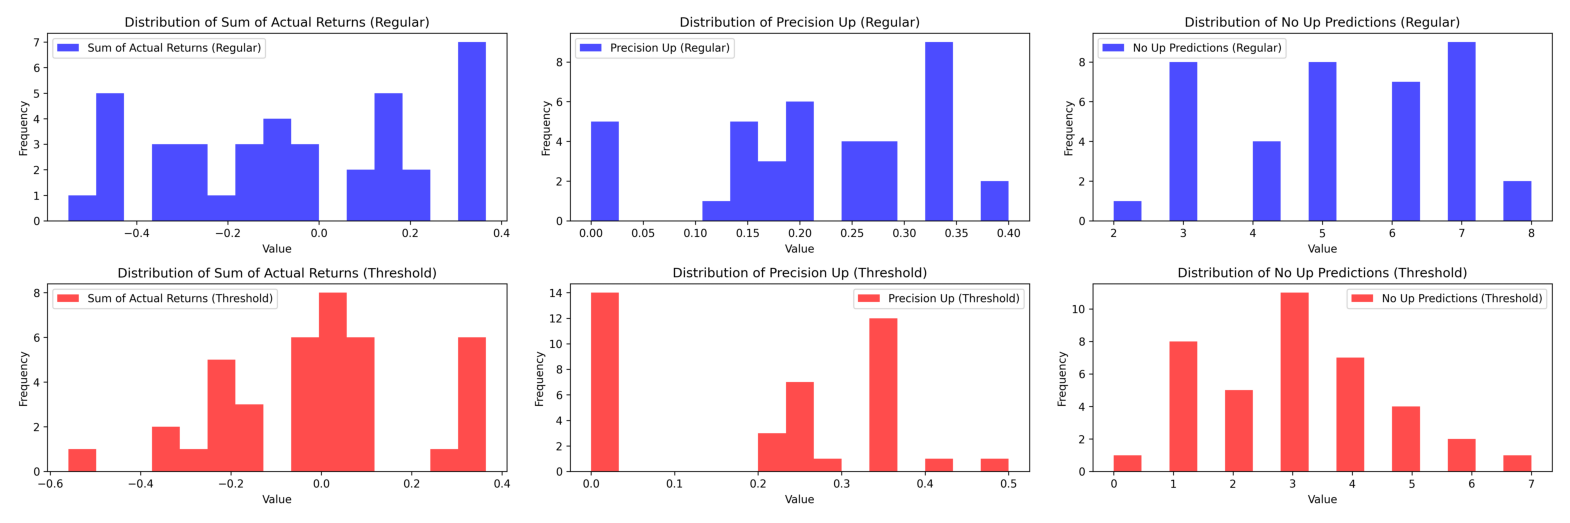

Threshold: 0.8


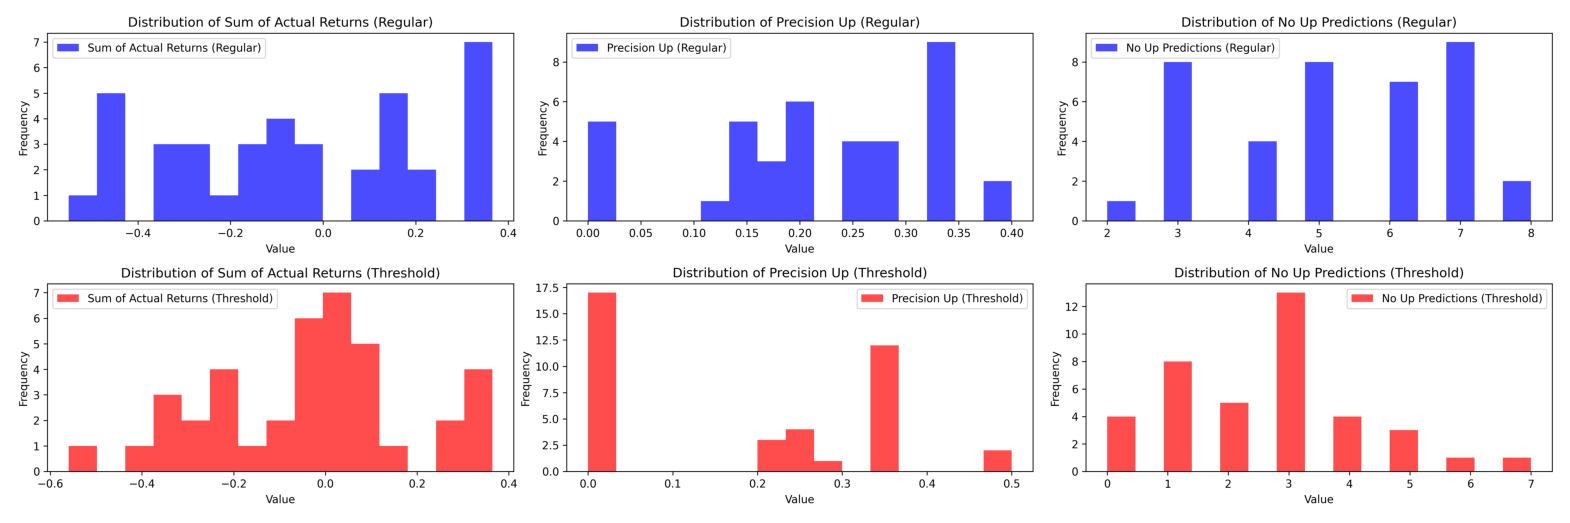

Threshold: 0.85


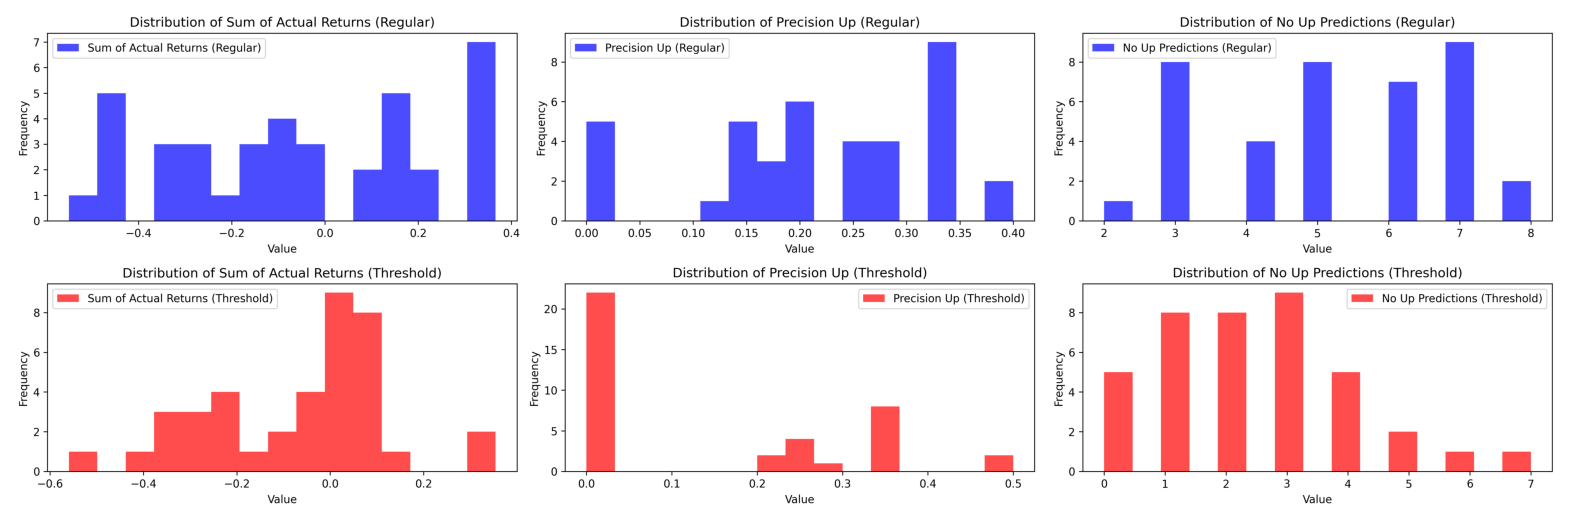

Threshold: 0.9


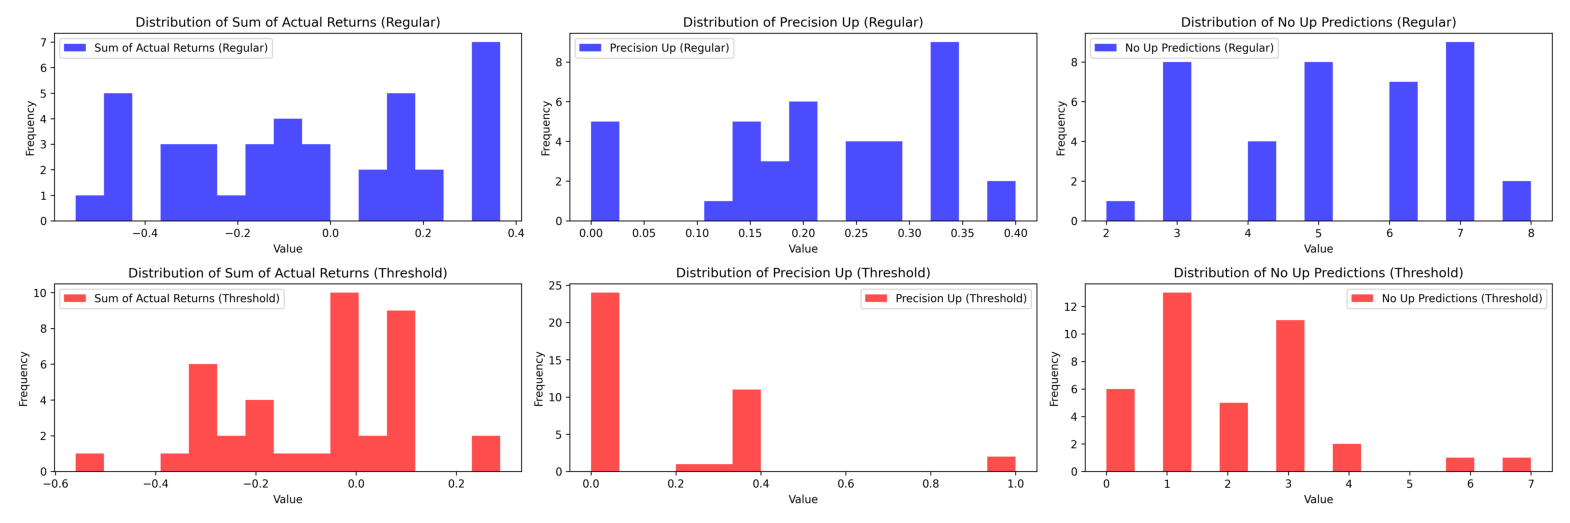

Threshold: 0.95


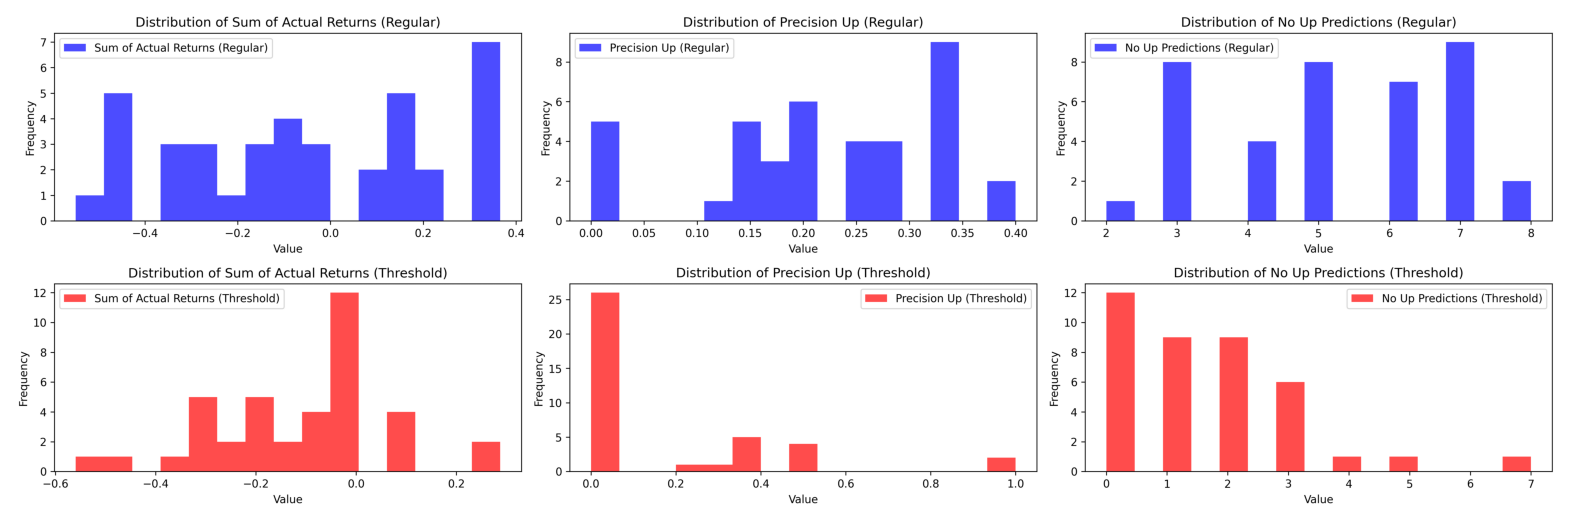

In [18]:
###### PURPOSE ---- RESULTS PLOTTING FROM THE CODE ABOVCE 


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

thresh , fig_bytes = zip(*res)

thresh2 , fig_bytes2 = zip(*res2)


# for th , fig_bytes in zip(thresh, fig_bytes):
#     print(f"Threshold: {th}")
#     plt.figure(figsize=(20, 19))
#     img = mpimg.imread(io.BytesIO(fig_bytes), format='png')
#     plt.imshow(img)
#     plt.axis('off')  # Hide axes
#     plt.show()


for th , fig_bytes in zip(thresh2, fig_bytes2):
    print(f"Threshold: {th}")
    plt.figure(figsize=(20, 19))
    img = mpimg.imread(io.BytesIO(fig_bytes), format='png')
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()
